### Importing all Required Libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2

### Reading the Image

In [4]:
# Reading a picture in grascale

image = cv2.imread('pexels-alexravvas-26611787.jpg', cv2.IMREAD_GRAYSCALE)
image2 = cv2.imread('pexels-alexravvas-26611787.jpg')
cv2.imshow('original', image)
cv2.waitKey(0)
cv2.destroyAllWindows()

### Displaying the Image Using Matplotlib

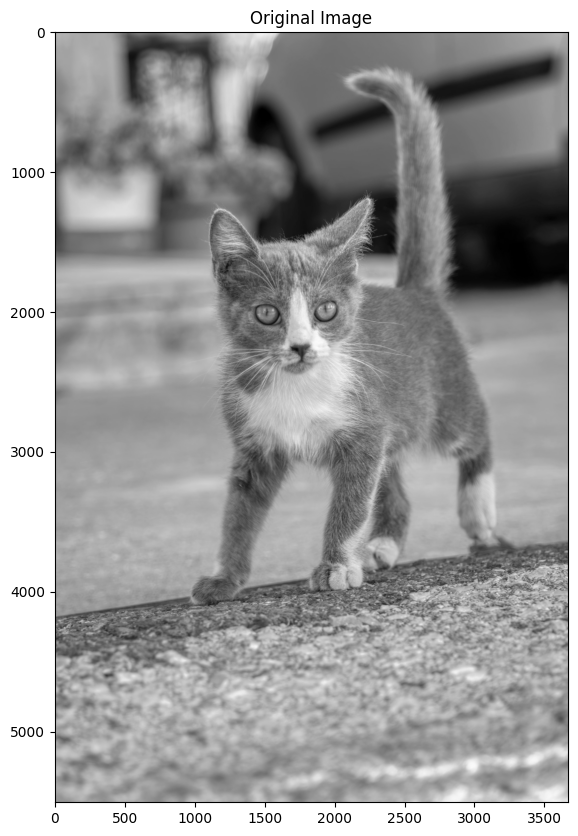

In [5]:
plt.figure(figsize = (10,10))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.show()

### Printing Shape of the Image

In [6]:
print(f" Shape of the Image:: {image.shape}")
print(f" Type of the Image:: {type(image)}")

 Shape of the Image:: (5506, 3671)
 Type of the Image:: <class 'numpy.ndarray'>


### Resizing the Image & Reshaping the Image

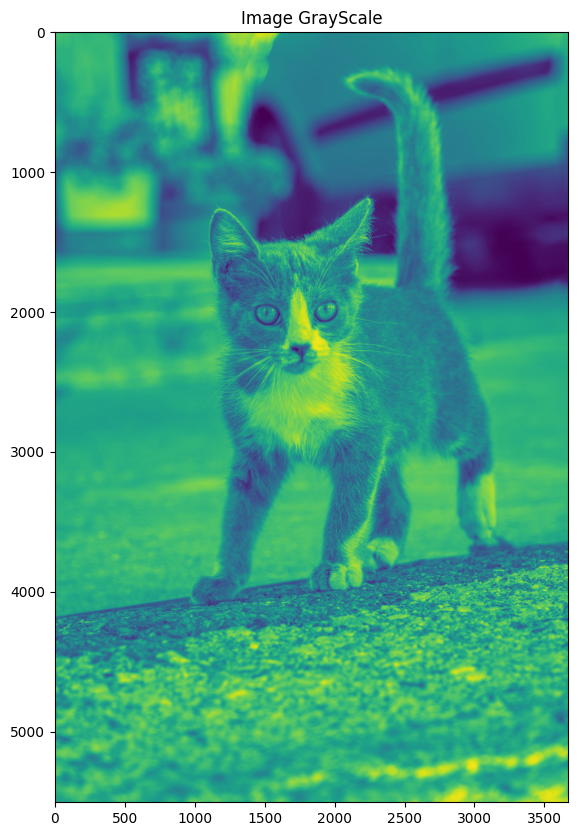

In [8]:
image1 = image.copy()
image3 = cv2.resize(image1,(500,500))
plt.figure(figsize = (10,10))
plt.imshow(image1)
plt.title('Image GrayScale')
plt.show()


### 

In [ ]:
bit_planes = []
for i in range(8):
    plane = (image1 >> i) 
    bit_planes.append(plane)

planes_to_keep = [i for i in range(8) if i not in [0,1]]

    

In [ ]:
reconstructed = np.zeros_like(image1 , dtype = np.uint8)
for i in planes_to_keep:
    reconstructed += ((bit_planes[i]) << i)


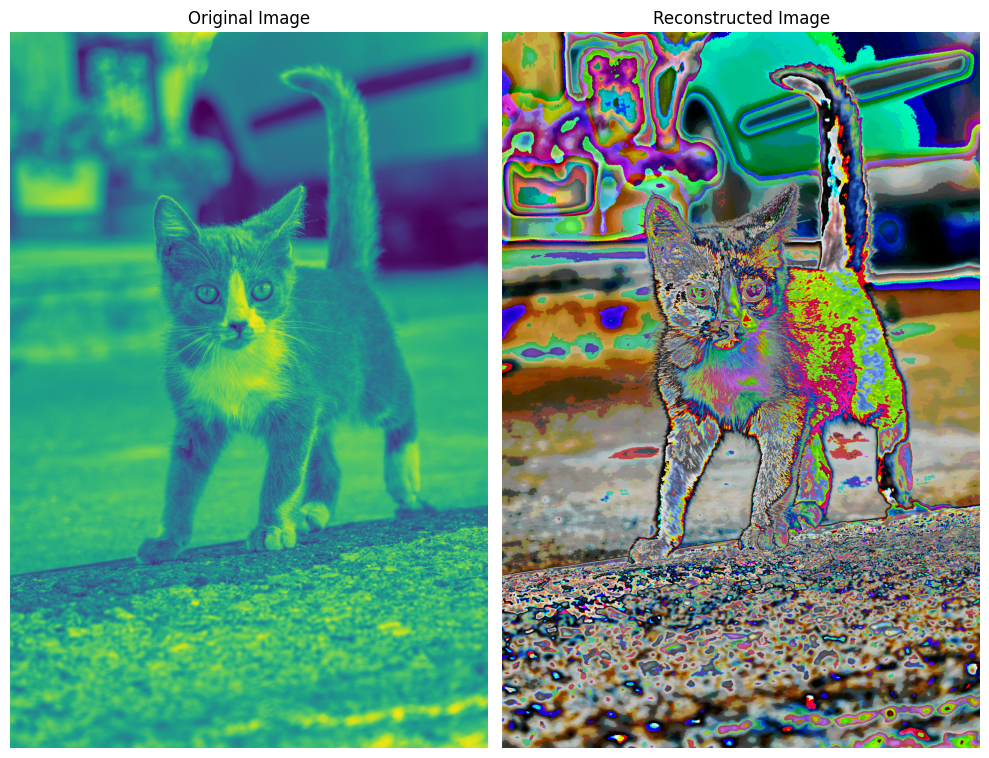

In [13]:
plt.figure(figsize = (10,10))
plt.subplot(1,2,1)
plt.imshow(image1)
plt.title('Original Image')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(reconstructed)
plt.title('Reconstructed Image')
plt.axis('off')
plt.tight_layout()



In [ ]:
# Displaying the Reconstructed Image


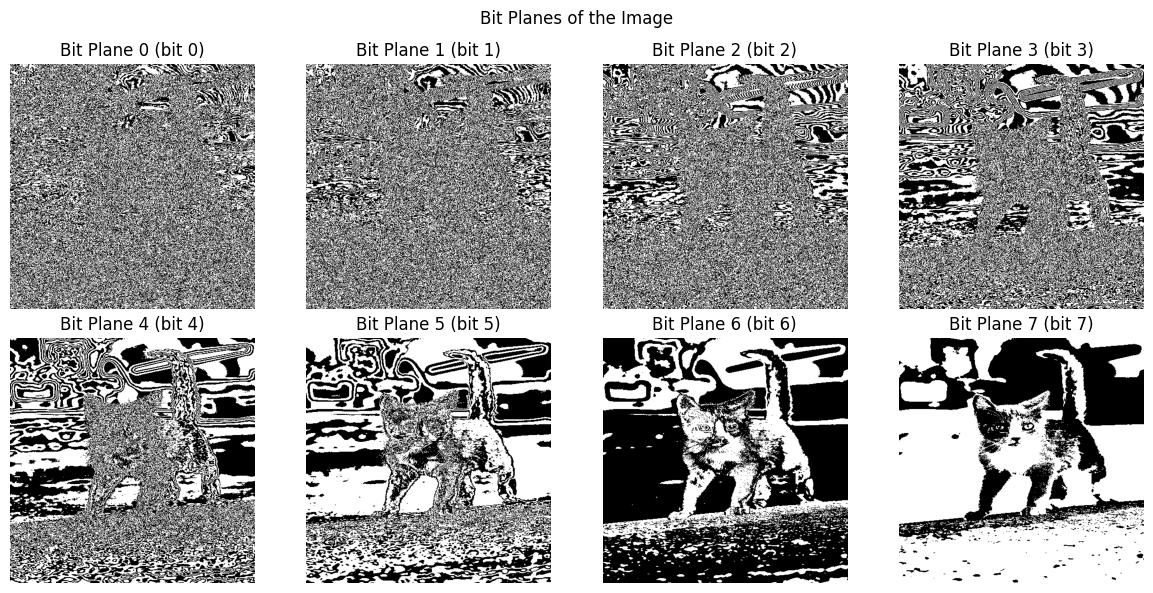

In [7]:
bit_planes = [(image2 >> i) & 1 for i in range(8)]
plt.figure(figsize = (12,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.title(f'Bit Plane {i} (bit {i})')
    plt.imshow(bit_planes[i], cmap='gray', vmin=0, vmax=1)
    plt.axis('off')

plt.suptitle('Bit Planes of the Image')
plt.tight_layout() 
plt.show() 

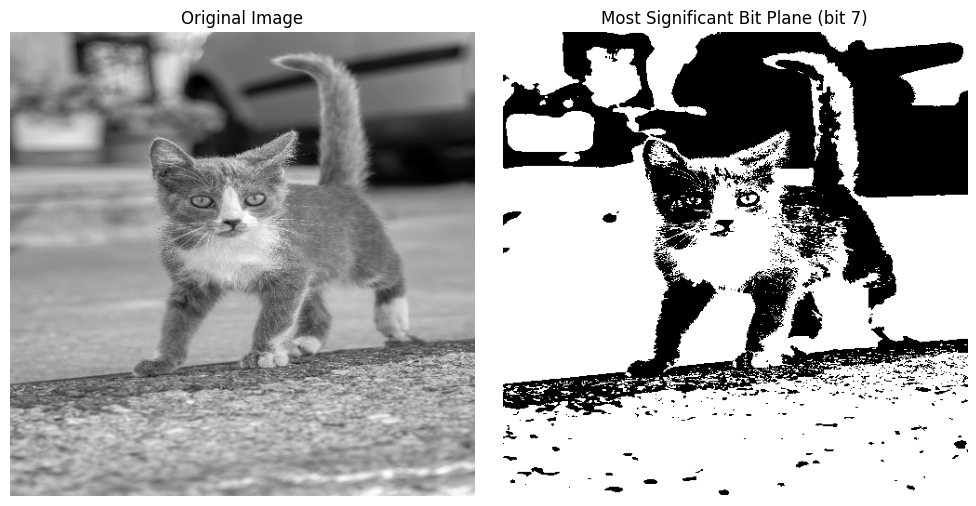

In [29]:
i = 7
msb_plane = (image2 >> i) & 1

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(image2, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(msb_plane, cmap='gray', vmin=0, vmax=1)
plt.title('Most Significant Bit Plane (bit 7)')
plt.axis('off')

plt.tight_layout()
plt.show()


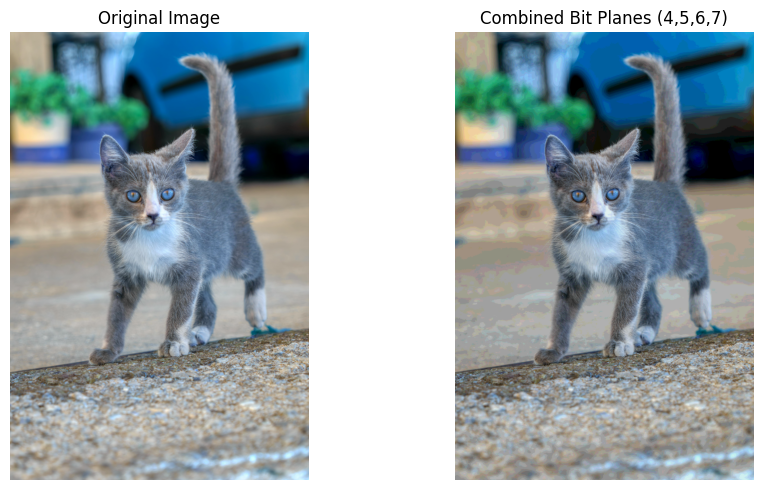

In [9]:
# Combine planes 4,5,6,7
image2 = cv2.imread('pexels-alexravvas-26611787.jpg')
combined = np.zeros_like(image2, dtype=np.uint8)

for i in [4, 5, 6, 7]:
    plane = (image2 >> i) & 1      # extract bit
    combined += (plane << i)      # shift back & add

# Display
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image2, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(combined)
plt.title('Combined Bit Planes (4,5,6,7)')
plt.axis('off')

plt.tight_layout()
plt.show()
